In [1]:
import igraph as ig
from google.cloud import bigquery
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import numpy as np
import random
import pandas as pd

In [2]:
modelText = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
modelCPC = SentenceTransformer('all-mpnet-base-v2')

In [2]:
query = """
        WITH
          refs AS (
            SELECT
              family_id,
              COUNT(DISTINCT family_reference) AS n_refs
            FROM staging_patent_clusters.family_refererences
            FULL JOIN unified_patents.metadata USING(family_id)
            GROUP BY family_id
          ),
          cits AS (
            SELECT
              family_reference AS family_id,
              COUNT(DISTINCT family_refererences.family_id) AS n_cits
            FROM staging_patent_clusters.family_refererences
            FULL JOIN unified_patents.metadata ON metadata.family_id = family_refererences.family_reference
            GROUP BY family_reference
          ),
          links AS (
            SELECT
              family_id,
              COALESCE(n_refs,0) + COALESCE(n_cits,0) AS n_links
            FROM refs
            FULL JOIN cits USING(family_id)
            ORDER BY n_links
          )

        SELECT
          n_links,
          COUNT(DISTINCT family_id) AS n_families
        FROM links
        GROUP BY n_links
        ORDER BY n_links
        """

In [3]:
client = bigquery.Client()

In [4]:
result = client.query(query)
link_counts = []
for row in result:
    link_counts.append([row['n_links'],row['n_families']])
link_counts = np.array(link_counts)

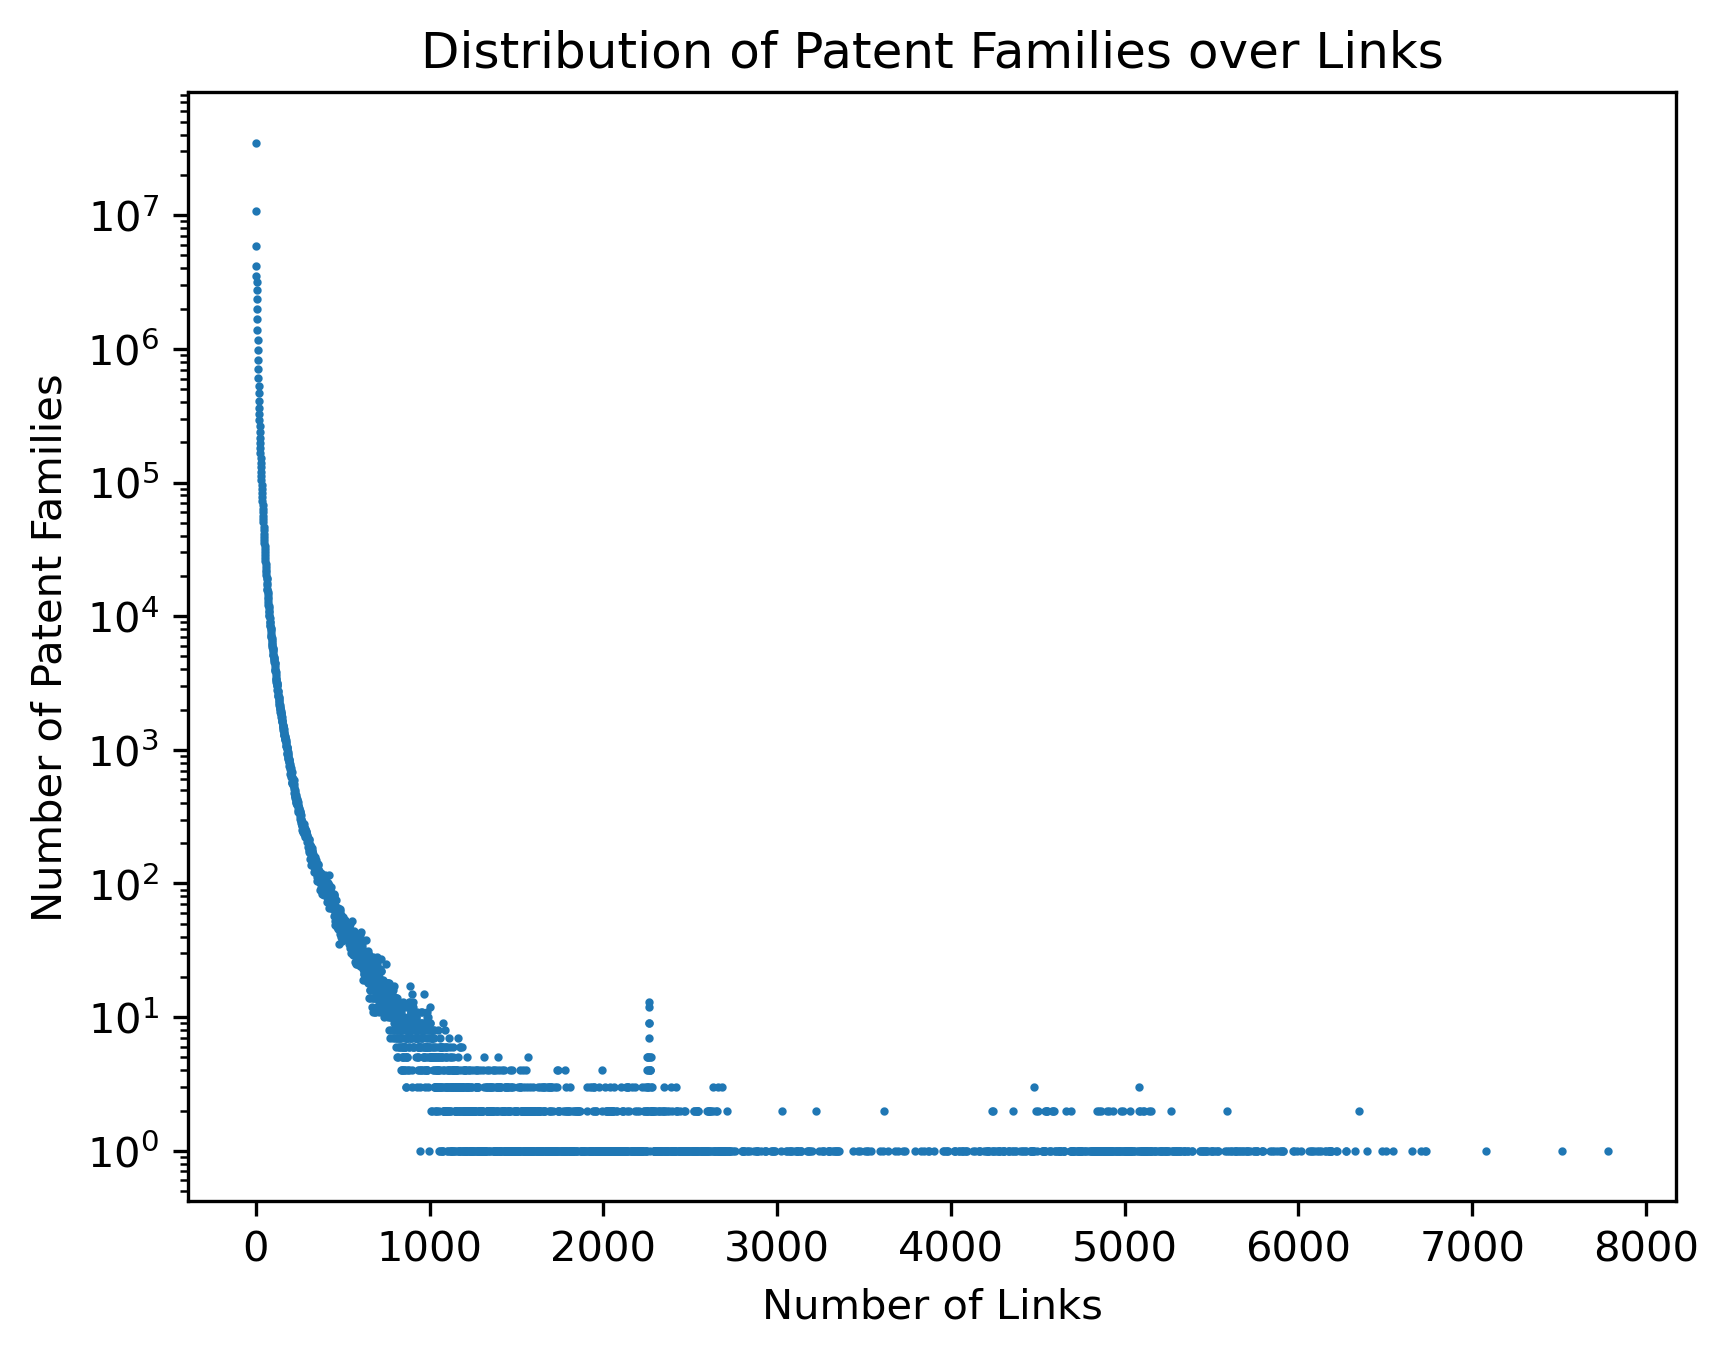

In [5]:
plt.figure(dpi=300)
plt.title('Distribution of Patent Families over Links')
plt.xlabel('Number of Links')
plt.ylabel('Number of Patent Families')
plt.scatter(link_counts.T[0],link_counts.T[1], s=1)
plt.yscale('log')
plt.show()

In [6]:
query_stats = """
                WITH
                  links AS (
                    SELECT
                      DISTINCT
                      family_id,
                      TRUE AS has_links
                    FROM staging_patent_clusters.family_refererences
                    UNION DISTINCT
                      SELECT
                        family_reference AS family_id,
                        TRUE AS has_links
                      FROM staging_patent_clusters.family_refererences
                  ),
                  cpc_text AS (
                    SELECT
                      DISTINCT
                      family_id,
                      TRUE AS has_cpc
                    FROM staging_patent_clusters.family_cpc_text
                  ),
                  title_abstract_text AS (
                    SELECT
                      DISTINCT
                      family_id,
                      TRUE AS has_text
                    FROM staging_patent_clusters.patents_to_embed
                  ),
                  all_families AS (
                    SELECT
                      DISTINCT
                      family_id
                    FROM unified_patents.metadata
                  )

                SELECT
                  has_links,
                  has_cpc,
                  has_text,
                  COUNT(DISTINCT family_id) AS n_families
                FROM links
                FULL JOIN cpc_text USING(family_id)
                FULL JOIN title_abstract_text USING(family_id)
                FULL JOIN all_families USING(family_id)
                GROUP BY has_links, has_cpc, has_text
            """

In [7]:
result = client.query(query_stats)

In [8]:
overlap_stats = {}
for row in result:
    if row['has_links']:
        links = 'has_links'
    else:
        links = 'no_links'
    if row['has_cpc']:
        cpc = 'has_cpc'
    else:
        cpc = 'no_cpc'
    if row['has_text']:
        text = 'has_text'
    else:
        text = 'no_text'
    overlap_stats[(links,cpc,text)] = row['n_families']

In [9]:
subset = (
    overlap_stats[('has_links','no_cpc','no_text')], # 0
    overlap_stats[('no_links','has_cpc','no_text')], # 1
    overlap_stats[('has_links','has_cpc','no_text')], # 2
    overlap_stats[('no_links','no_cpc','has_text')], # 3
    overlap_stats[('has_links','no_cpc','has_text')], #4
    overlap_stats[('no_links','has_cpc','has_text')], #5
    overlap_stats[('has_links','has_cpc','has_text')]
)

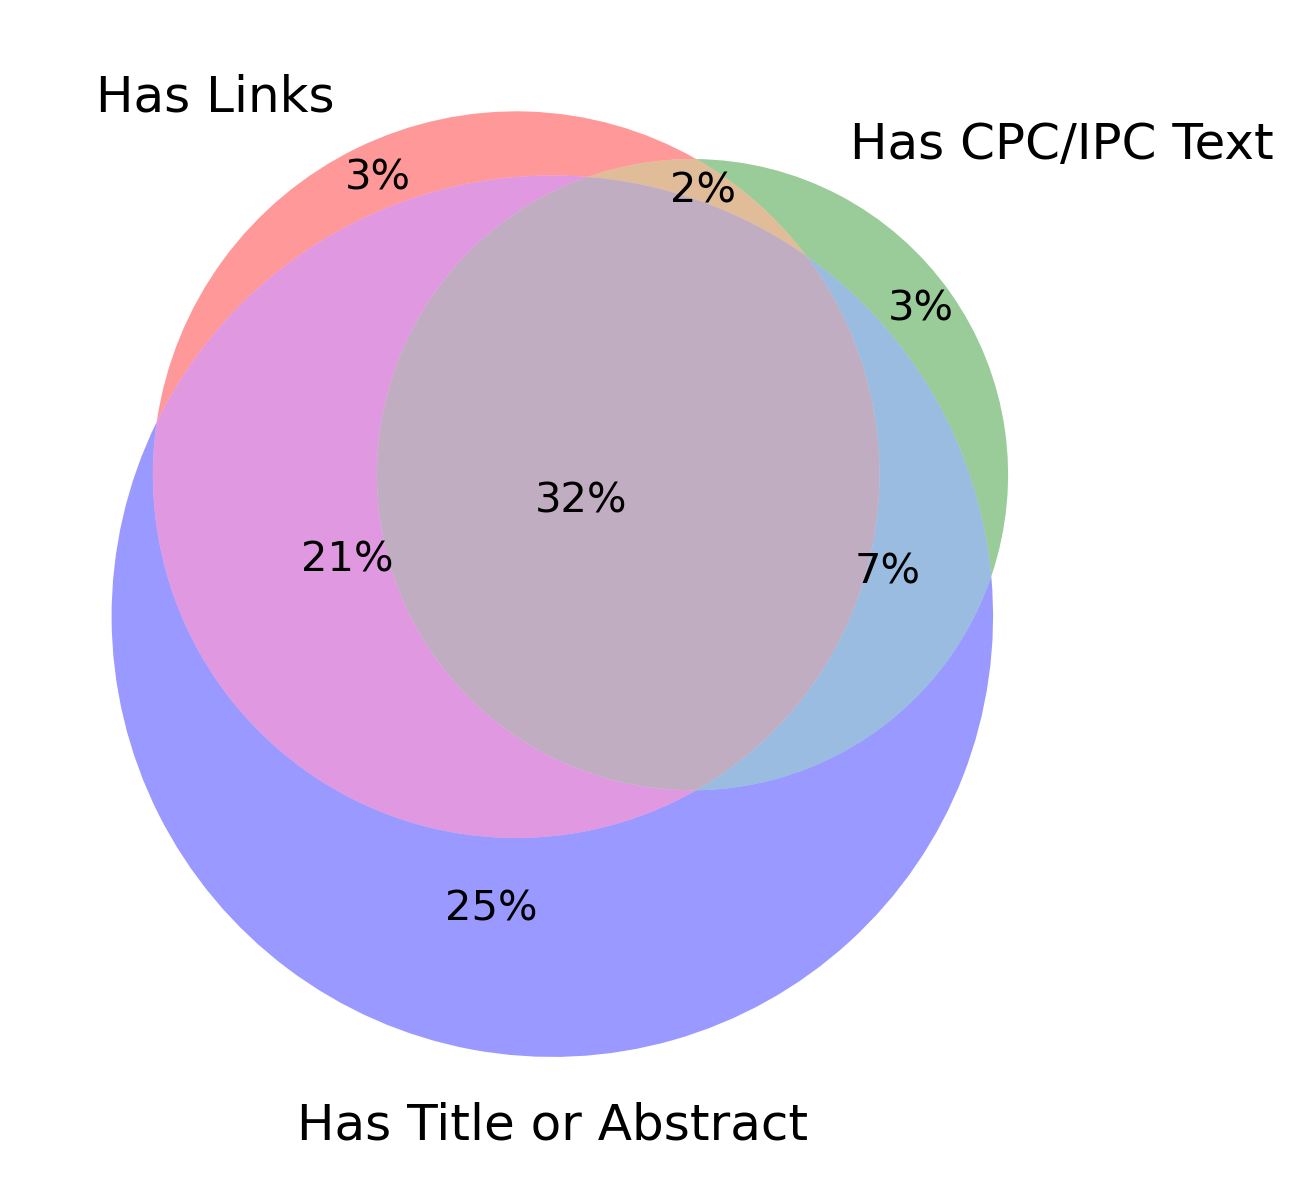

In [10]:
plt.figure(dpi=300)
total = sum([v for v in overlap_stats.values()])
venn3(subsets = subset, set_labels = ('Has Links', 'Has CPC/IPC Text', 'Has Title or Abstract'), subset_label_formatter=lambda x: f"{(x/total):1.0%}")
plt.show()

In [11]:
query = """
        WITH
          refs AS (
            SELECT
              family_id,
              family_reference
            FROM staging_patent_clusters.family_refererences
            WHERE family_id IN (SELECT family_id FROM staging_patent_clusters.patent_network_sample)
            AND family_reference IN (SELECT family_id AS family_reference FROM staging_patent_clusters.patent_network_sample)
          ),
          weights AS (
            SELECT
              family_id,
              1/COUNT(DISTINCT family_reference) AS weight
            FROM refs
            GROUP BY family_id
          )

        SELECT
          family_id,
          family_reference,
          weight
        FROM refs
        LEFT JOIN weights USING(family_id)
        """

In [12]:
result = client.query(query)

In [13]:
patent_samples = []
for row in result:
    patent_samples.append([row['family_id'] , row['family_reference'], row['weight']])
patent_samples = np.array(patent_samples)

In [14]:
edges = patent_samples[:,0:2]
#edges = [random.sample(range(10),2) for i in range(10)]
#edges = [[int(row[0]),int(row[1])] for row in edges]
weights = patent_samples.T[2]
#weights = [random.random() for i in range(10)]
weights = [float(w) for w in weights]

In [15]:
def label_mapping(labels):
    all_labels = []
    for row in labels:
        all_labels.extend(row)
    unique_labels = set(all_labels)
    mapping_forward = {}
    mapping_reverse = {}
    i = 0
    for k in unique_labels:
        mapping_forward[k] = i
        mapping_reverse[i] = k
        i += 1
    return mapping_forward, mapping_reverse

In [16]:
m_forward, m_reverse = label_mapping(edges)

In [17]:
edges_remapped = [[m_forward[row[0]],m_forward[row[1]]] for row in edges]

In [18]:
g = ig.Graph(edges = edges_remapped, edge_attrs = {'weights':weights})

In [19]:
layout = g.layout(layout='drl', weights="weights")

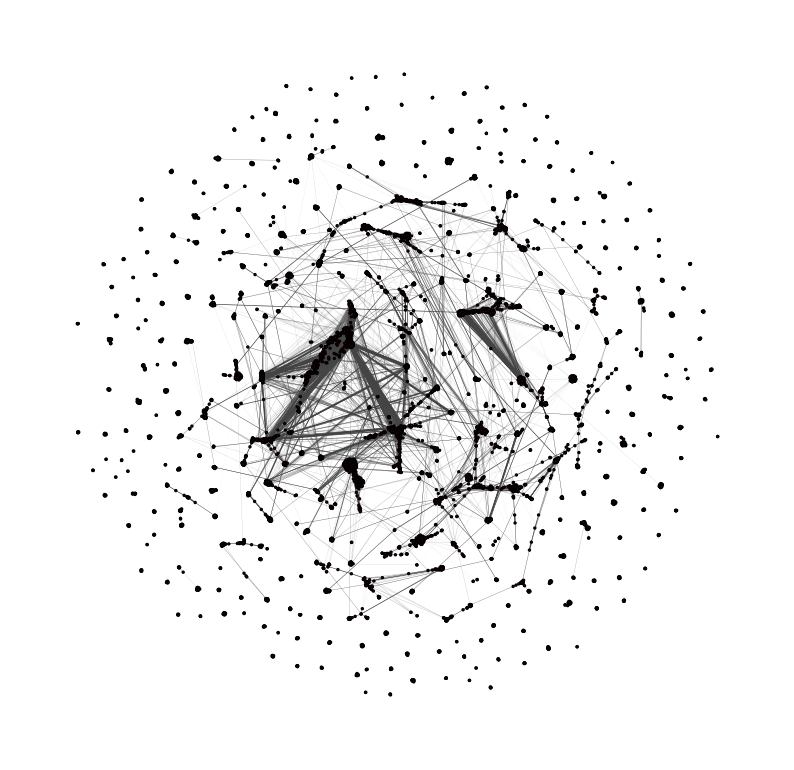

In [20]:
fig, ax = plt.subplots(figsize=(10,10))
ig.plot(g, layout=layout, target=ax, edge_width=g.es['weights'], vertex_size=2)
ax.set_aspect('equal')
plt.show()

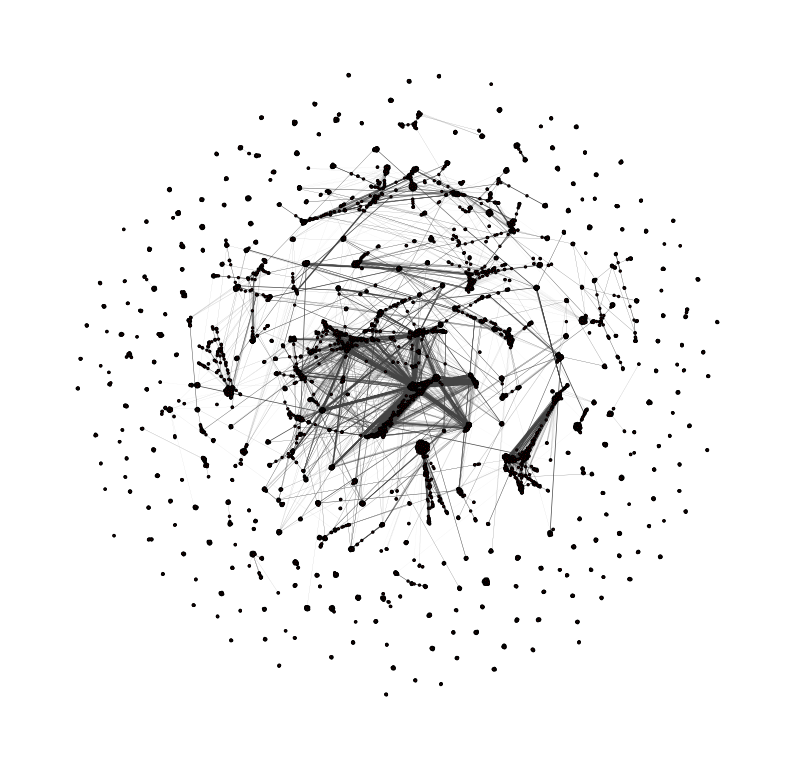

In [146]:
fig, ax = plt.subplots(figsize=(10,10))
ig.plot(g, layout=layout, target=ax, edge_width=g.es['weights'], vertex_size=2)
ax.set_aspect('equal')
plt.show()